# updated_sample_modeling

Full tree-based and ensemble modeling pipeline on teammate sample dataset with time-based split logic.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kruskal, wilcoxon
from sklearn.ensemble import RandomForestRegressor, StackingRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

ROOT = Path('..').resolve()
DATA = ROOT / 'data' / 'raw' / 'yellow_taxi_representative_sample_2021_2023_distribution.csv'
OUT_RESULTS = ROOT / 'reports' / 'results'
OUT_FIG = ROOT / 'reports' / 'figures'
OUT_RESULTS.mkdir(parents=True, exist_ok=True)
OUT_FIG.mkdir(parents=True, exist_ok=True)


def load_data(path):
    df = pd.read_csv(path)
    df['pickup_year'] = pd.to_numeric(df['pickup_year'], errors='coerce')
    df['pickup_month'] = pd.to_numeric(df['pickup_month'], errors='coerce')
    df['sample_rows'] = pd.to_numeric(df['sample_rows'], errors='coerce')
    df = df.dropna().copy()
    df['date'] = pd.to_datetime(df['pickup_year'].astype(int).astype(str) + '-' + df['pickup_month'].astype(int).astype(str).str.zfill(2) + '-01')
    df = df.sort_values('date').reset_index(drop=True)
    return df


def build_features(df):
    x = df.copy()
    x['year'] = x['date'].dt.year
    x['month'] = x['date'].dt.month
    x['quarter'] = x['date'].dt.quarter
    x['month_sin'] = np.sin(2*np.pi*x['month']/12)
    x['month_cos'] = np.cos(2*np.pi*x['month']/12)
    x['lag_1'] = x['sample_rows'].shift(1)
    x['lag_2'] = x['sample_rows'].shift(2)
    x['lag_3'] = x['sample_rows'].shift(3)
    x['roll_mean_3'] = x['sample_rows'].shift(1).rolling(3, min_periods=1).mean()
    x['roll_std_3'] = x['sample_rows'].shift(1).rolling(3, min_periods=1).std().fillna(0.0)
    return x.dropna().reset_index(drop=True)


def split_time(df):
    t = np.array(sorted(df['date'].unique()))
    n = len(t)
    tr_end = int(n*0.70)
    va_end = int(n*0.85)
    tr = df[df['date'].isin(set(t[:tr_end]))].copy()
    va = df[df['date'].isin(set(t[tr_end:va_end]))].copy()
    te = df[df['date'].isin(set(t[va_end:]))].copy()
    return tr, va, te


def metrics(y, p):
    return {
      'mae': float(mean_absolute_error(y,p)),
      'rmse': float(np.sqrt(mean_squared_error(y,p))),
      'r2': float(r2_score(y,p)),
      'residual_variance': float(np.var(y-p))
    }


In [2]:
df = load_data(DATA)
feat = build_features(df)
train, valid, test = split_time(feat)
print('raw:', df.shape, 'feat:', feat.shape, 'split:', len(train), len(valid), len(test))
feat.head()


raw: (36, 4) feat: (33, 14) split: 23 5 5


,pickup_year,pickup_month,sample_rows,date,year,month,quarter,month_sin,month_cos,lag_1,lag_2,lag_3,roll_mean_3,roll_std_3
0,2021,4,284,2021-04-01,2021,4,2,8.660254e-01,-0.500000,284.0,284.0,284.0,284.0,0.0
1,2021,5,284,2021-05-01,2021,5,2,5.000000e-01,-0.866025,284.0,284.0,284.0,284.0,0.0
2,2021,6,284,2021-06-01,2021,6,2,1.224647e-16,-1.000000,284.0,284.0,284.0,284.0,0.0
3,2021,7,284,2021-07-01,2021,7,3,-5.000000e-01,-0.866025,284.0,284.0,284.0,284.0,0.0
4,2021,8,284,2021-08-01,2021,8,3,-8.660254e-01,-0.500000,284.0,284.0,284.0,284.0,0.0


In [3]:
features = ['year','month','quarter','month_sin','month_cos','lag_1','lag_2','lag_3','roll_mean_3','roll_std_3']
target = 'sample_rows'

models = {
  'boosting_xgboost': XGBRegressor(n_estimators=120,max_depth=4,learning_rate=0.08,subsample=0.9,colsample_bytree=0.9,objective='reg:squarederror',random_state=42,n_jobs=1),
  'bagging_random_forest': RandomForestRegressor(n_estimators=200,max_depth=8,random_state=42,n_jobs=1),
  'stacking_ensemble': StackingRegressor(estimators=[('xgb', XGBRegressor(n_estimators=80,max_depth=3,learning_rate=0.1,objective='reg:squarederror',random_state=42,n_jobs=1)),('rf',RandomForestRegressor(n_estimators=120,random_state=42,n_jobs=1)),('hgb',HistGradientBoostingRegressor(max_depth=6,random_state=42))], final_estimator=RidgeCV(alphas=np.logspace(-3,3,13)), passthrough=True, cv=3, n_jobs=1)
}

rows=[]
preds=pd.DataFrame(index=test.index)
for n,m in models.items():
    m.fit(train[features], train[target])
    p = m.predict(test[features])
    preds[n]=p
    r=metrics(test[target].to_numpy(), p)
    r['model']=n
    rows.append(r)

model_df=pd.DataFrame(rows).sort_values('mae').reset_index(drop=True)
model_df.to_csv(OUT_RESULTS/'model_comparison.csv', index=False)
pred_out = test[['date',target]].copy()
for c in preds.columns: pred_out[f'pred_{c}']=preds[c].values
pred_out.to_csv(OUT_RESULTS/'test_predictions.csv', index=False)
model_df


,mae,rmse,r2,residual_variance,model
0,1.212091,1.275717,-9.171595,0.158290,boosting_xgboost
1,3.116000,3.139414,-60.599500,0.146464,bagging_random_forest
2,11.133362,11.140817,-774.736238,0.166038,stacking_ensemble


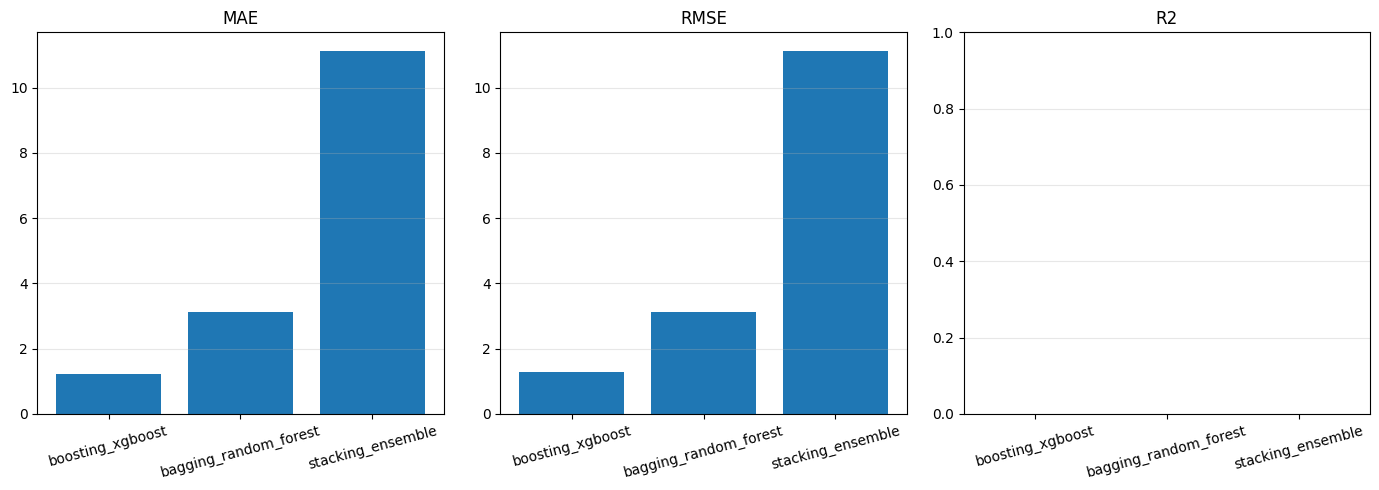

In [4]:
fig,axes=plt.subplots(1,3,figsize=(14,5))
m=model_df
axes[0].bar(m['model'],m['mae']); axes[0].set_title('MAE')
axes[1].bar(m['model'],m['rmse']); axes[1].set_title('RMSE')
axes[2].bar(m['model'],m['r2']); axes[2].set_title('R2'); axes[2].set_ylim(0,1)
for ax in axes:
    ax.tick_params(axis='x',rotation=15); ax.grid(axis='y',alpha=0.3)
fig.tight_layout(); fig.savefig(OUT_FIG/'model_metrics.png',dpi=200); plt.show()


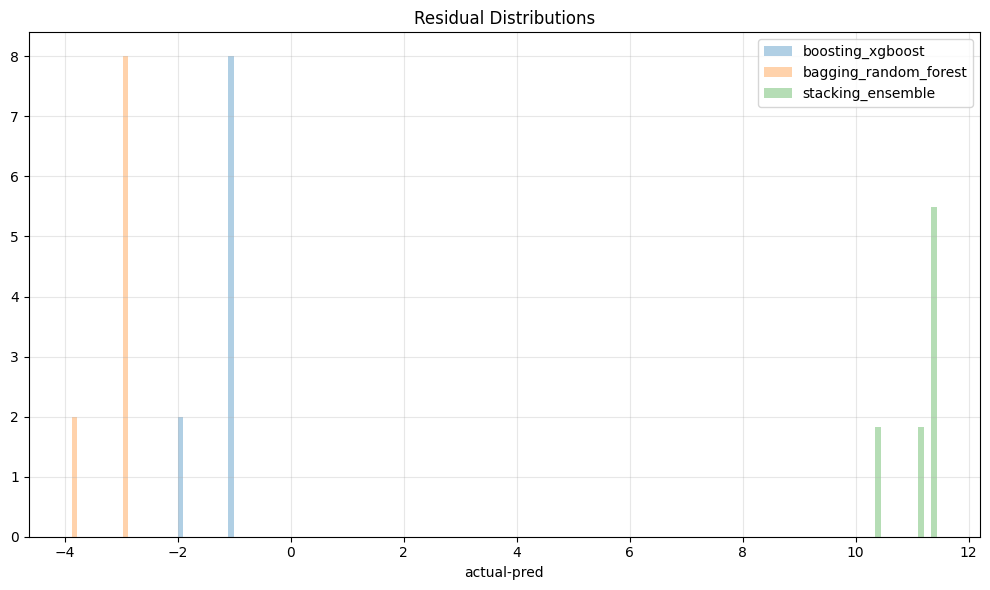

In [5]:
plt.figure(figsize=(10,6))
for c in preds.columns:
    resid = test[target].to_numpy() - preds[c].to_numpy()
    plt.hist(resid,bins=10,alpha=0.35,density=True,label=c)
plt.legend(); plt.grid(alpha=0.3); plt.title('Residual Distributions'); plt.xlabel('actual-pred')
plt.tight_layout(); plt.savefig(OUT_FIG/'error_distributions.png',dpi=200); plt.show()


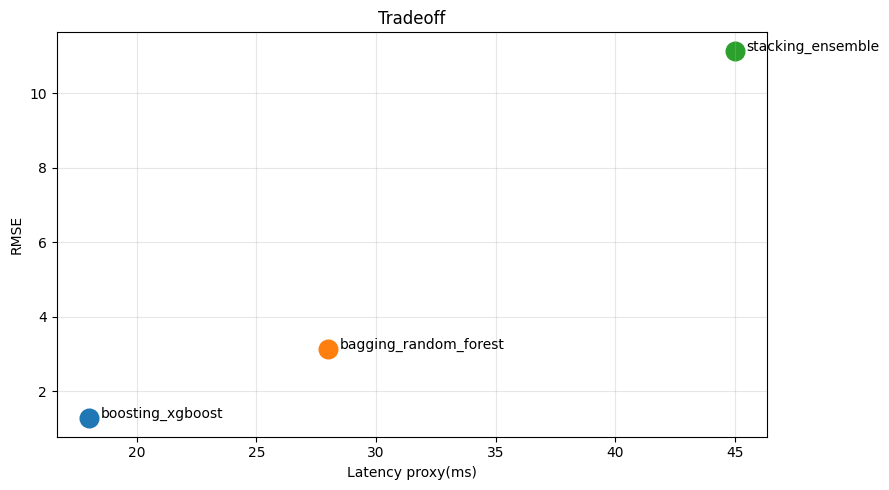

In [6]:
lat={'boosting_xgboost':18,'bagging_random_forest':28,'stacking_ensemble':45}
plt.figure(figsize=(9,5))
for _,r in model_df.iterrows():
    x=lat.get(r['model'],30); y=r['rmse']; plt.scatter(x,y,s=180); plt.text(x+0.5,y,r['model'])
plt.grid(alpha=0.3); plt.xlabel('Latency proxy(ms)'); plt.ylabel('RMSE'); plt.title('Tradeoff')
plt.tight_layout(); plt.savefig(OUT_FIG/'model_tradeoff.png',dpi=200); plt.show()
